# 05 — Proportional-integral-derivative

**Three terms, three jobs: present, past, future.**

Notebook 03 gave the loop a term that answers *what is the error now*, and it settled short of
the setpoint. Notebook 04 added a term that answers *what has the error been*, and it arrived —
and overshot by more than 40% of the step doing it, because an integrator has no way to know the
arrival is coming.

This notebook adds the term that does know. The derivative watches how fast the error is
closing and starts removing torque while the error is still large, so the loop brakes on
approach instead of braking on arrival. The same step, the same gain, the same car: the
overshoot falls from 44% to 3%.

The three notebooks have been one Dyad model with two booleans flipped throughout, and this is
the notebook where that pays off, because the comparison below is genuinely like for like.

## Setup

Same bootstrap as every notebook in this set, and the torque ceiling stays lifted — assume for
now an engine that delivers whatever we ask; notebook 06 removes that assumption.

In [1]:
isdefined(Main, :Lecture01Support) || include("support.jl")

# Bound by hand rather than with `using`. If this kernel ever ran an earlier `include` of
# support.jl there are two copies of the module, every name both export is ambiguous, and no
# amount of re-running `using` resolves it. An explicit binding does, so this cell repairs a
# kernel in that state instead of needing it restarted. Editing support.jl still needs a
# restart, because the guard above deliberately will not load a second copy.
for n in names(Lecture01Support)
    n === :Lecture01Support && continue
    Core.eval(Main, :($n = Lecture01Support.$n))
end

In [2]:
setup()

Main.VehicleSystemsComponents

## 1. The third path

$$
u(t) \;=\; k\left[\,\underbrace{e(t)}_{\text{now}} \;+\; \underbrace{\frac{1}{T_i}\int_0^{t} e(\tau)\,d\tau}_{\text{so far}} \;+\; \underbrace{T_d\,\frac{d e(t)}{dt}}_{\text{next}}\,\right]
$$

The derivative term responds to the *rate* at which the error is changing, not to its size. Two
consequences follow immediately, and they are the whole term.

**It is zero whenever nothing is moving.** At the start of the step, before anything happens,
and at the end, once the loop has settled, the derivative contributes exactly nothing. It cannot
help with steady-state error and it cannot hurt it. Whatever it does, it does only in the middle.

**It opposes fast approach.** Closing on the setpoint from below means the error is shrinking,
so its derivative is negative, so the term subtracts from the command — hardest exactly when the
approach is fastest. The proportional term is still asking for torque, because the error is
still positive and it can see nothing else; the derivative term is already taking it away.

That is the difference between braking when you arrive and braking when you can see that you are
going to. `T_d`, the derivative time, is how far ahead it looks.

## 2. Two decisions before the first run

The derivative is the one term that cannot be dropped into this loop without saying how, and
both decisions below are visible in the code rather than hidden in the model. Neither is a
detail of this car; both are what anyone differentiating a signal in a feedback loop has to
settle.

**The derivative acts on the measurement, not on the error** — `wd = 0` in `LimPID`'s setpoint
weighting. The error here is `setpoint - speed`, and the setpoint is a *step*: at the instant it
moves, its rate of change is infinite. Differentiating it produces a spike whose size is set by
the derivative filter rather than by anything about the car — in this loop, a command of about
12,000 N.m in the first instant, ten times anything else in the run.
That spike is called derivative kick, and the standard answer is to point the derivative at the
measured speed instead. The car's speed cannot step, so there is nothing to kick. Everything
said in section 1 still holds, because away from the instant of the step the setpoint is
constant and the two are the same signal with a sign.

**The derivative filter starts where the measurement is** — `xd0 = -90`. A real derivative is
not implementable, so `LimPID` uses a filtered one, and that filter has a state which has to
start somewhere. Its default is zero, which claims the filter has been looking at a speed of
zero, so the car appears to arrive from nothing the moment the run starts and the term produces
a spike four times the size of the one we just removed, with the wrong sign. Starting the state
at the speed the car is actually doing is what "the loop was already running before we started
watching" means numerically.

`CruiseLoop` does not expose `xd0`, so it is set with `rerun`, which re-solves the compiled
model with a parameter overridden rather than building a second one.

### The model this runs

Still `CruiseLoop`, unchanged since notebook 03. All three controllers in this lecture — P, PI
and PID — are one Dyad component with two boolean parameters between them, which is worth
noticing: the difference between the controllers is not three programs but two switches.

Source: [`dyad/Lecture1/CruiseLoop.dyad`](../../dyad/Lecture1/CruiseLoop.dyad), and the plant it
closes around in [`dyad/Vehicle/CarPlant.dyad`](../../dyad/Vehicle/CarPlant.dyad). Run
`show_dyad("CruiseLoop")` in any cell to read the declaration here rather than opening the file.


        settled [km/h]   error [km/h]   overshoot   peak [km/h]
  P     109.2899         0.7101         39.0 %      117.81
  PI    110.0001         -0.0001        44.1 %      118.82
  PID   110.0014         -0.0018        3.1 %       110.61


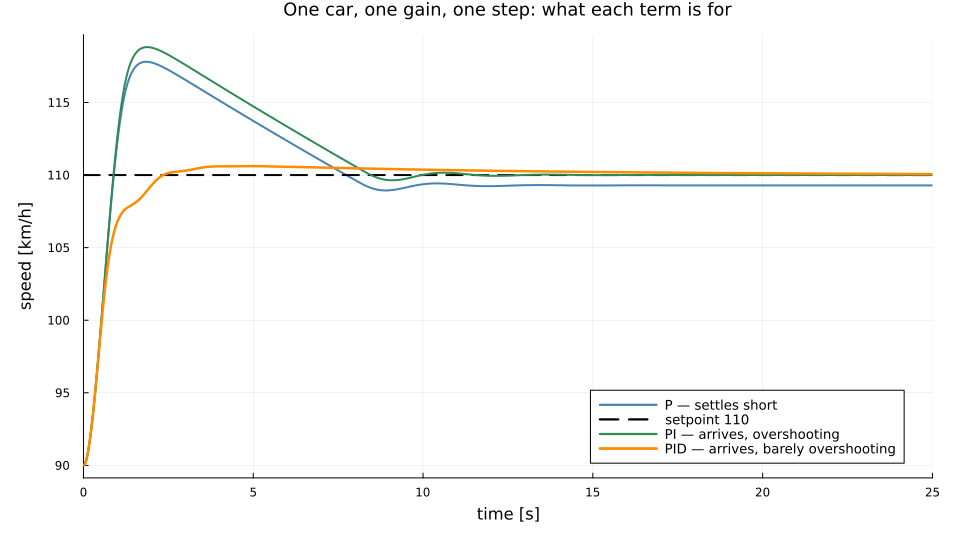

In [3]:
Scenarios = VehicleSystemsComponents.Lecture1

SPEED = "loop.plant.v_kmh"
SETPOINT = 110.0        # km/h
V_START = 90.0          # km/h — where the car is before the step
GAIN = 56.0             # N.m per km/h
T_I = 10.0              # s
T_D = 0.5               # s
UNLIMITED = 1.0e6       # N.m

controller(; with_I, with_D) =
    Scenarios.CruiseLoopStep(; name = :CruiseLoopStep, with_I = with_I, with_D = with_D)

p_only = Scenarios.CruiseLoopTransient(
    k = GAIN, T_max = UNLIMITED, y_max = UNLIMITED, stop = 60.0)
pi_loop = Scenarios.CruiseLoopTransient(
    model = controller(with_I = true, with_D = false),
    k = GAIN, Ti = T_I, T_max = UNLIMITED, y_max = UNLIMITED, stop = 60.0)
pid_loop = rerun(
    Scenarios.CruiseLoopTransient(
        model = controller(with_I = true, with_D = true),
        k = GAIN, Ti = T_I, Td = T_D, wd = 0.0,
        T_max = UNLIMITED, y_max = UNLIMITED, stop = 60.0),
    "loop.controller.xd0" => -V_START)

println("        settled [km/h]   error [km/h]   overshoot   peak [km/h]")
for (name, run) in (("P  ", p_only), ("PI ", pi_loop), ("PID", pid_loop))
    println("  ", name,
        "   ", rpad(round(signal(run, SPEED)[2][end], digits = 4), 16),
        " ", rpad(round(steady_state_error(run, SETPOINT; sig = SPEED), digits = 4), 14),
        " ", rpad(string(round(overshoot(run, SETPOINT; sig = SPEED), digits = 1), " %"), 11),
        " ", round(maximum(signal(run, SPEED)[2]), digits = 2))
end

plt = plot_speed(p_only; sig = SPEED, setpoint = SETPOINT, label = "P — settles short",
                 color = :steelblue, legend = :bottomright, xlims = (0, 25),
                 title = "One car, one gain, one step: what each term is for")
plot!(plt, signal(pi_loop, SPEED)...; label = "PI — arrives, overshooting", lw = 2, color = :seagreen)
plot!(plt, signal(pid_loop, SPEED)...; label = "PID — arrives, barely overshooting",
      lw = 2.5, color = :darkorange)
save_figure(plt, "05-p-pi-pid")
plt

That plot is the spine of the lecture, and it is worth saying what it does and does not show.

**Proportional** gets most of the way in a few seconds and stops 0.71 km/h short, because a
controller whose only output is `k·e` cannot hold torque at zero error.

**Proportional-integral** closes that gap exactly, and pays 44% overshoot for it. The integrator
is still accumulating while the car is still arriving, so it ends the approach holding more
torque than the car needs and the excess has to be spent on the far side of the setpoint.

**Proportional-integral-derivative** closes the same gap and overshoots by 3%. Nothing about the
steady state changed — the derivative is zero at both ends, so the settled point is the
integrator's, exactly as it was. What changed is the middle.

Watch where the orange curve leaves the green one. It is already below it at 95 km/h, a
long way from the setpoint and about seven tenths of a second into the run: the speed is climbing
fast, so the derivative is subtracting torque, and it does not wait for the error to be small
before doing so. The approach costs perhaps half a second more than PI's does. The arrival costs
nothing at all — by four seconds the orange curve is flat, while the green one is still coming
down through 115 km/h.

That is the trade in one sentence. Braking earlier means arriving a little later, and it is very
much cheaper than arriving early and then having to come back.

## 3. The three contributions

The three terms are added, so they can be separated. Below is each path's contribution to the
command, in N.m — each block's output multiplied by `k`, which is where the gain is applied in
`LimPID` — together with the torque the controller actually asks the engine for.

                        at t = 0     peak      settled
  proportional  1120.0       1120.0    -0.077 N.m
  integral      0.0          79.6      40.188 N.m
  derivative    0.0          715.9     0.004 N.m
  commanded     1120.0       1120.1    40.116 N.m


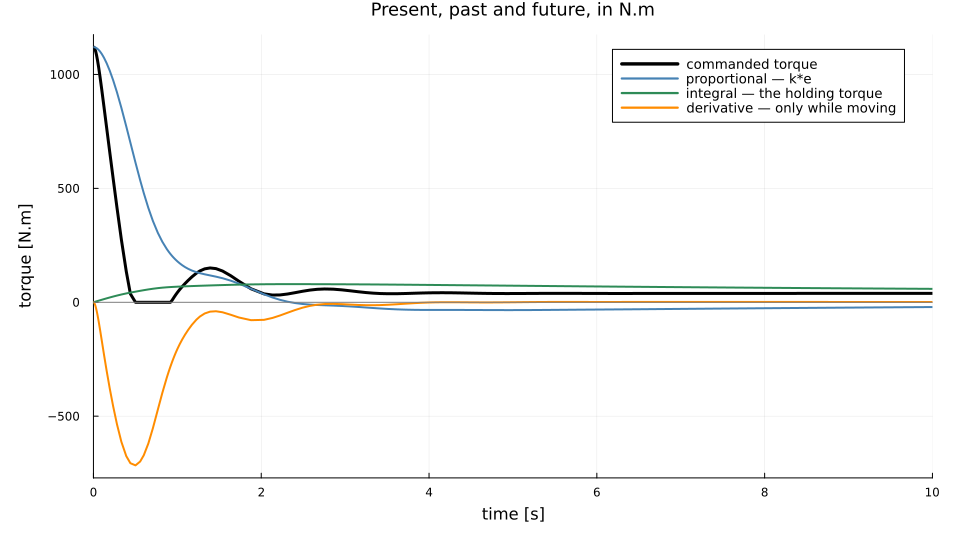

In [4]:
contribution(run, path) = (signal(run, path)[1], GAIN .* signal(run, path)[2])

t_p, u_p = contribution(pid_loop, "loop.controller.proportional.y")
t_i, u_i = contribution(pid_loop, "loop.controller.integrator.y")
t_d, u_d = contribution(pid_loop, "loop.controller.derivative.y")
t_u, u_cmd = signal(pid_loop, "loop.controller.y")

println("                        at t = 0     peak      settled")
for (name, u) in (("proportional", u_p), ("integral    ", u_i), ("derivative  ", u_d),
                  ("commanded   ", u_cmd))
    println("  ", name, "  ", rpad(round(first(u), digits = 1), 12),
            " ", rpad(round(maximum(abs, u), digits = 1), 9),
            " ", round(last(u), digits = 3), " N.m")
end

plt = plot(t_u, u_cmd; lw = 3, color = :black, label = "commanded torque",
           xlabel = "time [s]", ylabel = "torque [N.m]", xlims = (0, 10),
           title = "Present, past and future, in N.m", legend = :topright)
plot!(plt, t_p, u_p; lw = 2, color = :steelblue, label = "proportional — k*e")
plot!(plt, t_i, u_i; lw = 2, color = :seagreen, label = "integral — the holding torque")
plot!(plt, t_d, u_d; lw = 2, color = :darkorange, label = "derivative — only while moving")
hline!(plt, [0.0]; color = :grey, lw = 1, label = "")
save_figure(plt, "05-three-contributions")
plt

Each curve does exactly the job its name claims, and the ends of the run are where that is
clearest.

**Proportional carries the transient and then vanishes.** It starts at 1120 N.m — the full
20 km/h of error times the gain — and falls to zero as the error closes. At the end of the run
it contributes nothing at all, which is the whole of notebook 03 in one line.

**Integral holds the steady state.** It starts at zero, since nothing has been accumulated yet,
overshoots to about 80 N.m, and comes back down to 40.19 N.m by the end of the run — still
converging, slowly, on the 40.119 N.m that notebook 04 followed out to ninety seconds. Whatever
the car is being asked for once it has settled comes from this one curve.

**Derivative exists only while the error is moving.** Zero at the start, zero at the end, a
single large negative excursion in between — it takes about 700 N.m out of the command during
the fastest part of the approach, which is the 40% of overshoot that the PI loop spent and this
one did not.

**And the commanded torque is not always their sum.** For about four tenths of a second from
`t = 0.55` the three terms add up to a negative number and the command sits flat on zero, because
the engine has no braking torque to give: `y_min = 0`. The loop asks for the hardest deceleration
available to it, which is no torque at all, and then waits. Lifting the ceiling made the engine
arbitrarily strong; it did not make it able to pull backwards.

## 4. Choosing Td

`T_d` is how far ahead the derivative looks, and the sweep below holds everything else fixed.

  Td [s]    overshoot    settled [km/h]
  0.1       28.8 %       110.0
  0.25      9.8 %        110.001
  0.5       3.1 %        110.001
  1.0       7.3 %        110.063
  2.0       17.9 %       110.827
  4.0       40.0 %       111.605


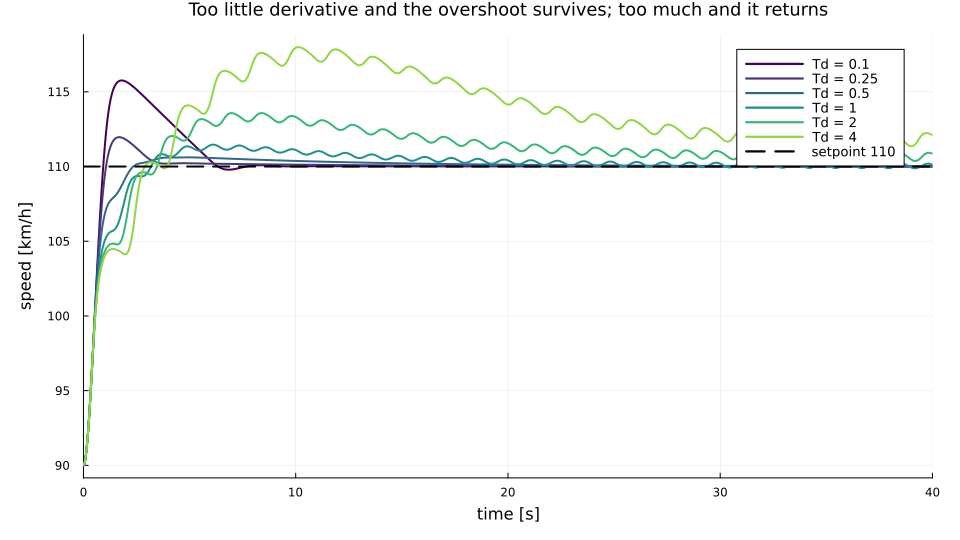

In [5]:
TDS = [0.1, 0.25, 0.5, 1.0, 2.0, 4.0]

td_family = sweep(pid_loop, "Td", TDS)

println("  Td [s]    overshoot    settled [km/h]")
for (td, sol) in td_family
    println("  ", rpad(td, 8),
            "  ", rpad(string(round(overshoot(sol, SETPOINT; sig = SPEED), digits = 1), " %"), 11),
            "  ", round(signal(sol, SPEED)[2][end], digits = 3))
end

plt = plot_sweep(td_family; sig = SPEED, setpoint = SETPOINT, name = "Td",
                 title = "Too little derivative and the overshoot survives; too much and it returns",
                 legend = :topright, xlims = (0, 40))
save_figure(plt, "05-td-family")
plt

The overshoot does not fall monotonically with `T_d` — it bottoms out and comes back:

| `Td` | 0.1 | 0.25 | **0.5** | 1.0 | 2.0 | 4.0 |
|---|---|---|---|---|---|---|
| overshoot | 28.8% | 9.8% | **3.1%** | 7.3% | 17.9% | 40.0% |

**Too little and there is not enough braking.** At `Td = 0.1` s the derivative is looking a tenth
of a second ahead, which on a loop that crosses 20 km/h in about a second is barely ahead at all,
and most of the PI overshoot survives.

**Too much and the term starts fighting its own loop.** Past `Td = 1` s the curves grow a visible
ripple and take far longer to come down — the two largest have not finished settling when the run
ends — and by `Td = 4` s the overshoot is back where PI left it. A derivative
term that dominates is reacting to rate rather than to position, so the loop chases its own
changes: it brakes, the braking slows the approach, the reduced rate withdraws the braking, and
around it goes. On a real car, with a real speed sensor, it is also the term that amplifies
measurement noise — the reason `LimPID` filters it at all, and the subject of notebook 07.

Somewhere in the middle it is right, and `Td = 0.5` s is the best of these six. That is tuning:
not a formula, a shape with a bottom to find. Notebook 08 asks whether the classical tuning
tables can find it without a search.

## 5. Naming the variants

Zeroing one of these gains does not weaken a path, it removes it — and every combination that
leaves has a name, because every one of them is the right controller for something.

| | what is in the loop | when it is the right answer |
|---|---|---|
| **P** | present only | the plant needs no steady output, or the offset does not matter |
| **PI** | present and past | almost every process loop ever built: flow, level, temperature, speed |
| **PD** | present and future | a plant with its own integrator already, where adding another causes trouble |
| **PID** | all three | a loop that must arrive, arrive quickly, and not overshoot doing it |

Notebooks 03, 04 and 05 have been the same Dyad component throughout, with `with_I` and `with_D`
flipped — three compiled models from one piece of source, and the reason the comparison in
section 2 is honest. Nothing about the car, the step, the gain or the solver changed between
those three curves. The only difference was which paths existed.

That is also why the PID acronym has always been slightly misleading. It is not three
controllers glued together or a formula with three fitting constants. It is three questions
about one error signal — *what is it, what has it been, where is it going* — and a decision
about which of them this particular plant needs answered.

## What this bought us

A loop that arrives, arrives in a few seconds, and overshoots by 0.6 km/h on a 20 km/h step. On
a car that on its own takes a minute to respond to anything. That is a cruise controller anyone
would be happy to ship.

Except for the sentence at the top of every notebook since 03: *assume for now an engine that
delivers whatever we ask*. The command in section 3 peaks at 1120 N.m against an engine that has
150. Every result in these three notebooks is the behavior of the linear design, and the linear
design has been quietly spending seven times the torque the car actually has.

**Notebook 06** stops lifting the ceiling. The proportional term handles that gracefully enough —
it simply asks for more than it gets. The integrator does not, because it has no way to know the
engine has run out, and it goes on accumulating against an error it is no longer able to correct.
That is integral windup, and it is the failure that anti-windup exists to prevent.